# Neuroinformatics: Modeling Neurons Spiking Responses to External Stimuli

This report has been implemented by Ali Al-Dulaimi, 1019322 aaldulaimi@uni-osnabrueck.de

1. Data Loading + Visualization
2. Neural Coding Methods
    *   Rate coding
    *   Sparsity coding
    *   Frequency coding  
3. Feature Extraction + Exploratory Data Analysis
    *   KL Divergence:
        *   X_frequency: top neurons
        *   X_rate: averaged
        *   X_sparsity (single-numbered)
    *   Histograms

4. Model Fitting
5. Performance Evaluation
6. Performance Improvement Strategies:
  *   Train Naive Bayes on:
    *   X_rate
    *   X_sparsity
    *   X_frequency
  *   Train multiple classification models on the best performing features:
    *   Logistic Regression
    *   Random Forests
    *   MLB
    *   SVM
  *   Train best performing model on a combination of features:
    *   np.hstack([X_rate, X_sparsity, X_frequency])
  
  *   Train best performing model, best performing features set:
    *   Selecting neuron's with highest information
  *   Dimensionality reduction (PCA) on all X_frequency neurons and then best performing model


7. Extra

In [4]:
# to keep the connection while working on colab
from IPython.display import Javascript

def keep_colab_alive():
    script = """
    function ClickConnect(){
        console.log("Running ClickConnect()");
        document.querySelector("colab-connect-button").shadowRoot.querySelector("#connect").click();
    }
    setInterval(ClickConnect, 60000);
    """
    display(Javascript(script))

keep_colab_alive()

<IPython.core.display.Javascript object>

### Task: to develop a binary classifier that determines, based on the neural activity, whether a given stimulus was familiar or unfamiliar.

- Kandel et al., Principles of Neural Science: external stimuli (like light, touch, or sound) trigger neurons to produce electrical impulses (spikes), which are the fundamental unit of neural activity.

Data is composed of 800 entries each is a matrix of 1000 neurons and a time window of length 501 time steps

In [5]:
import numpy as np
from zipfile import ZipFile
from matplotlib import pyplot as plt
from scipy.fft import fft
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

## 1. Data Loading + Visualization

#### 1.1. Data Loading

In [6]:
with ZipFile('/content/data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [7]:
X = np.load('/content/x.npy')
y = np.load('/content/y.npy')

X.shape, y.shape

((800, 1000, 501), (800,))

#### 1.2. Data Visualization

<ipython-input-8-872c56ccbf8a>:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


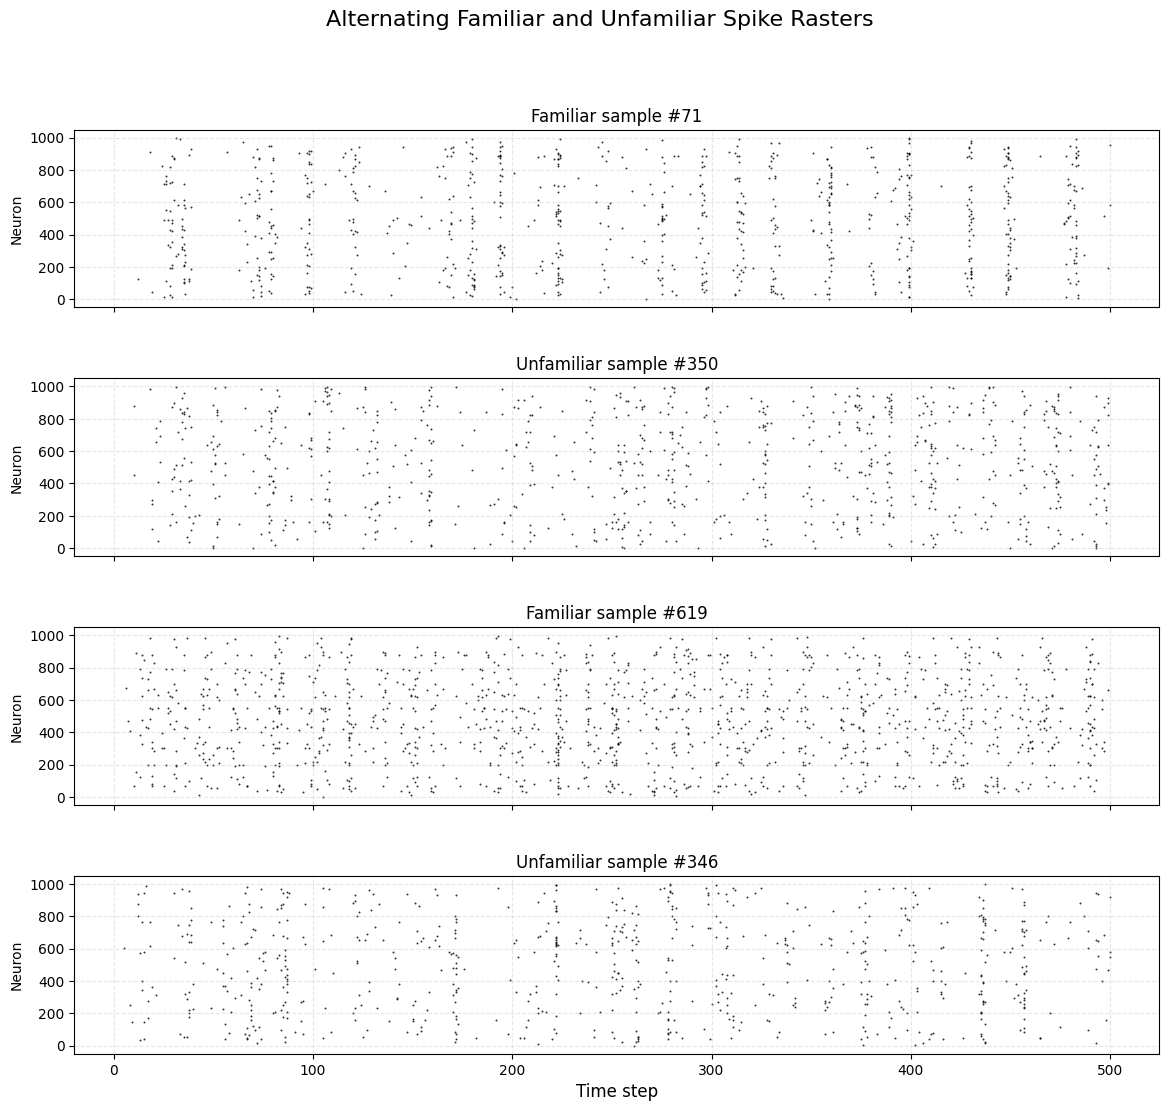

In [8]:
def plot_alternating_rasters(X, y, seed=42):

    rng = np.random.default_rng(seed)
    # generate 2 + 2 random indices for familiar and unfamiliar samples
    familiar_idx = rng.choice(np.where(y == 1)[0], size=2, replace=False)
    unfamiliar_idx = rng.choice(np.where(y == 0)[0], size=2, replace=False)

    """
    we first show familiar then unfamiliar samples twice such that we can "compare"
    visually between their spiking behavior
    """
    sample_indices = np.array([familiar_idx[0], unfamiliar_idx[0], familiar_idx[1], unfamiliar_idx[1]])
    labels = ['Familiar', 'Unfamiliar', 'Familiar', 'Unfamiliar']

    n_neurons = X.shape[1]

    fig, axes = plt.subplots(
        4, 1, figsize=(14, 12), sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.4}
    )


    for ax, sample_id, label in zip(axes, sample_indices, labels):
        sample = X[sample_id]

        for neuron_idx in range(n_neurons):
            # finding spikes
            spike_times = np.where(sample[neuron_idx] > 0)[0]
            ax.scatter(
                spike_times,
                np.full_like(spike_times, neuron_idx),
                s=2, alpha=0.8, color='black', linewidths=0
            )

        ax.set_ylabel("Neuron", fontsize=10)
        ax.set_title(f"{label} sample #{sample_id}", fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.3)

    axes[-1].set_xlabel("Time step", fontsize=12)
    plt.suptitle("Alternating Familiar and Unfamiliar Spike Rasters", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_alternating_rasters(X, y)

## 2. Neural Coding Methods

We are going to use the following data processing methods:

* Firing Rate Coding

* Sparsity Coding

* Frequency Coding


> Firing Rate Coding (how much neurons fire) =>	Average number of spikes per neuron over time, Very simple, very biologically meaningful, easy for Logistic Regression or any classifier

> Sparsity Coding (how many neurons are involved) =>	Fraction of neurons that fired at least once, Captures "distributed vs. sparse" population coding. Familiar stimuli may activate more neurons in a coordinated way, whereas unfamiliar stimuli might result in sparse or disorganized firing. Sparsity features also showed a large KL divergence between familiar and unfamiliar classes, suggesting strong discriminative power for classification.

> Frequency Coding (how spikes are distributed across time patterns (bursty or rhythmic)) => (Fourier Transform)	How much "power" is in low-frequency components of spike trains, Captures possible rhythmic or oscillatory neural patterns; performed very well in classification (85% accuracy!)
Frequency domain features can reveal temporal structures such as bursts or rhythmic firing, which might differ between familiar and unfamiliar stimuli. Frequency coding provided excellent classification performance (85% accuracy), confirming its relevance for this task.


Reasons I chose these methods:
- They are fast to compute and easy to interpret.

- Easy to implement.

- Easy to interpret

In [9]:
class FeatureExtraction:
    def __init__(self, X, y):
        # original dataset (800 x 1000 x 501)
        self.X = X
        self.y = y

    def rate_coding(self):
        # averaging or collapsong dimension 2 (repreents the timesteps for each neuron)
        rate_features = np.mean(self.X, axis=2)
        return rate_features

    def sparsity_coding(self):
        # here we try to find the proportion of firing neurons for each sample
        # this line generate a binary vector that we next calculate the mean/percentage
        active_neurons = np.any(self.X > 0, axis=2)
        sparsity_features = np.mean(active_neurons, axis=1).reshape(-1, 1)
        return sparsity_features

    def frequency_coding(self, low_freq_bins=5):
        n_samples, n_neurons, n_timesteps = self.X.shape
        frequency_features = np.zeros((n_samples, n_neurons))
        for i in range(n_samples): # over 800
            for j in range(n_neurons): # over 1000
                spike_train = self.X[i, j] # fast Fourier transform over 501 timesteps
                spike_fft = np.abs(fft(spike_train)) # take only the real part of FFT
                # sum the components after the first index 0 of each neuron until bin `low_freq_bins`
                frequency_features[i, j] = np.sum(spike_fft[1:low_freq_bins+1])

        return frequency_features

#### What we expect from each feature extractor method:
> rate_coding()	=> (800, neurons) firing rates

> sparsity_coding() =>	(800, 1) sparsity feature

> frequency_coding() => (800, neurons) low-frequency power

In [10]:
extractor = FeatureExtraction(X, y)

X_rate = extractor.rate_coding()
X_sparsity = extractor.sparsity_coding()
X_frequency = extractor.frequency_coding(low_freq_bins=10) # low_freq_bins=10 only improved the performance by ~1-2%

print(X_rate.shape)       # (800, 1000)
print(X_sparsity.shape)   # (800, 1)
print(X_frequency.shape)  # (800, 1000)

(800, 1000)
(800, 1)
(800, 1000)


In **rate coding**, we collapse over the time axis by **averaging spike activity per neuron**, keeping all neurons as features. In **sparsity coding**, we first collapse over time by checking if a neuron spiked at all, and then collapse across neurons **to compute the fraction of active neurons for each sample**. In **frequency coding**, we collapse over the time axis by applying a Fourier transform to each neuron's spike train, and then** summarize the low-frequency components by summing their magnitudes**. We keep all neurons as features, with each feature reflecting the strength of slow oscillations in that neuron's firing activity.

## 3. Exploratory Data Analysis

We used **KL divergence** to quantify the difference between **familiar and unfamiliar feature distributions**. KL divergence is a natural choice for comparing probability distributions, **as it measures how much information is lost when one distribution is used to approximate another**. A **high** KL divergence indicates **strong separability **between classes, which is ideal for classification tasks.

#### 3.1 Class Balance Visualization

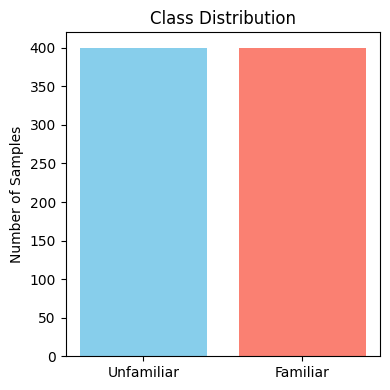

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_balance(y, class_names=('Unfamiliar', 'Familiar')):
    counts = np.bincount(y)
    plt.figure(figsize=(4, 4))
    plt.bar(class_names, counts, color=['skyblue', 'salmon'])
    plt.title("Class Distribution")
    plt.ylabel("Number of Samples")
    plt.tight_layout()
    plt.show()

plot_class_balance(y)

#### 3.2 Neural Coding Methods

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

class NeuralCodingExploratoryAnalysis:
    def __init__(self, X, y, feature_type='rate'):
        # original dataset
        self.X = X
        self.y = y
        # holding current step
        self.feature_type = feature_type
        self.familiar = X[y == 1]
        self.unfamiliar = X[y == 0]
        # an array that holds all kl values between each neuron inidex between the familiar and unfamiliar items (400 each)
        self.kl_divergences = self._compute_all_kl()

    def _kl_divergence_1d(self, p, q, bins):
        """Symmetrized KL divergence"""
        p_hist, _ = np.histogram(p, bins=bins, density=True)
        q_hist, _ = np.histogram(q, bins=bins, density=True)
        p_hist += 1e-10
        q_hist += 1e-10
        kl1 = entropy(p_hist, q_hist)
        kl2 = entropy(q_hist, p_hist)
        return 0.5 * (kl1 + kl2)

    def _compute_all_kl(self, bins=30):
        """Compute KL divergence per feature"""
        divergences = []
        for i in range(self.X.shape[1]):
            kl = self._kl_divergence_1d(self.familiar[:, i], self.unfamiliar[:, i], bins)
            divergences.append(kl)
        return np.array(divergences)

    def get_top_k_features(self, k=3):
        """Return indices of top-k most informative features (by KL divergence)"""
        return np.argsort(self.kl_divergences)[-k:][::-1]

    def plot_distributions(self, feature_indices=None, top_k=None, bins=30):
        """Plot selected or top-K features"""
        if top_k is not None:
            feature_indices = self.get_top_k_features(k=top_k)

        if feature_indices is None:
            raise ValueError("Provide feature_indices or top_k")

        for idx in feature_indices:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(self.familiar[:, idx], label='Familiar', fill=True)
            sns.kdeplot(self.unfamiliar[:, idx], label='Unfamiliar', fill=True)
            plt.title(f'{self.feature_type.capitalize()} Feature {idx} (KL={self.kl_divergences[idx]:.3f})')
            plt.xlabel('Value')
            plt.ylabel('Density')
            plt.legend()
            plt.tight_layout()
            plt.show()

    def summary(self):
        num_familiar = np.sum(self.y == 1) # or 400 each
        num_unfamiliar = np.sum(self.y == 0)

        print(f"Class balance: {num_familiar} familiar, {num_unfamiliar} unfamiliar")
        print(f"Average KL Divergence: {np.mean(self.kl_divergences):.4f}")
        top_k = self.get_top_k_features(3)
        print(f"Top 3 informative features (by KL): {top_k} with values {self.kl_divergences[top_k]}")

This class offers us:
1. Automatically selecting most informative neurons.

2. Improving visual interpretability.

3. Output is useful for feature selection in modeling later.

Class balance: 400 familiar, 400 unfamiliar
Average KL Divergence: 3.1505
Top 3 informative features (by KL): [862 694 689] with values [8.87482488 8.48296894 8.37555711]


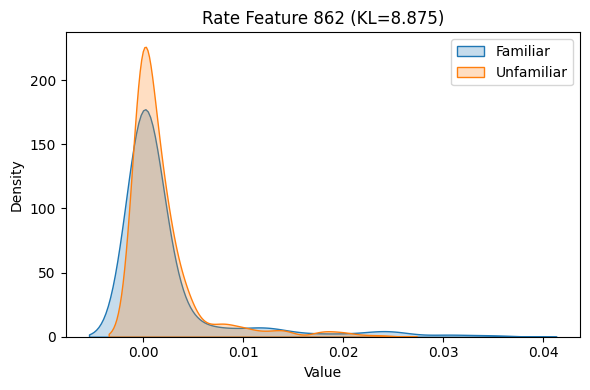

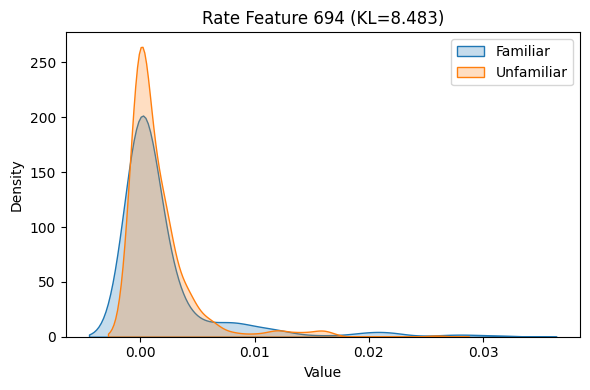

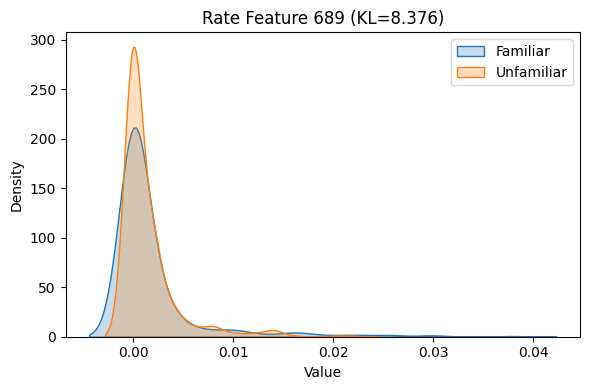

Class balance: 400 familiar, 400 unfamiliar
Average KL Divergence: 0.4361
Top 3 informative features (by KL): [0] with values [0.43609842]


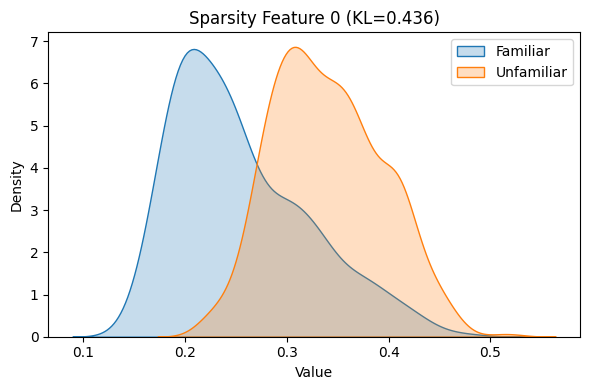

Class balance: 400 familiar, 400 unfamiliar
Average KL Divergence: 1.5761
Top 3 informative features (by KL): [198 177 855] with values [5.19428114 4.90323318 4.78828462]


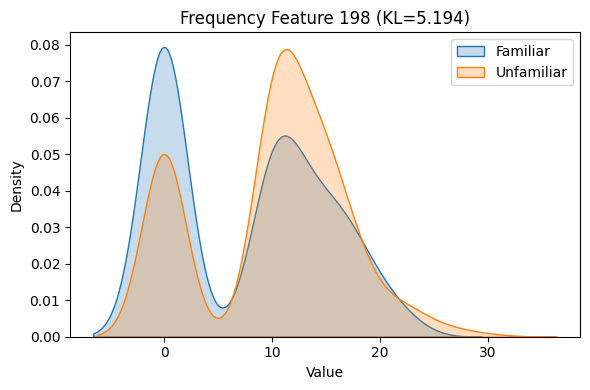

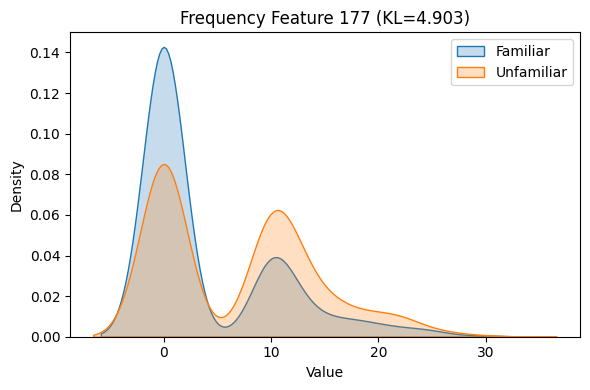

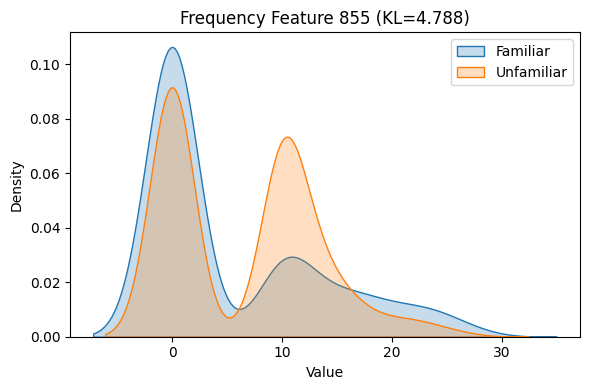

In [13]:
# Rate coding
eda_rate = NeuralCodingExploratoryAnalysis(X_rate, y, feature_type='rate')
eda_rate.summary()
eda_rate.plot_distributions(top_k=3)

# Sparsity coding
eda_freq = NeuralCodingExploratoryAnalysis(X_sparsity, y, feature_type='sparsity')
eda_freq.summary()
eda_freq.plot_distributions(top_k=3)

# Frequency coding
eda_freq = NeuralCodingExploratoryAnalysis(X_frequency, y, feature_type='frequency')
eda_freq.summary()
eda_freq.plot_distributions(top_k=3)

## 4. Model Fitting

We chose **Naive Bayes** as a baseline model driven by **Occam's Razor principle** since NB is simple, interpretable, good baseline, handles continuous features easily. In the later steps we will compare the accuracy of different classification models too!

NB also also provides probabilistic outputs that allow analysis of model confidence. Given the size and nature of our feature sets, NB offers an ideal trade-off between performance and interpretability.

Given the **small size of our dataset (800 rows)** and the low computational cost of NB, it provides an excellent starting point before exploring more complex classifiers. We will later compare its performance against more models such as **Logistic Regression, Random Forests, MLPs, and SVMs** to assess trade-offs between accuracy and interpretability.

#### 4.1 Naive Bayes on X_Rate features

In [14]:
# a generic utility function that takes a model, X, y, and a name and fits, tests the models, and returns the classification resutls
def train_and_evaluate_model(model, X_features, y, model_name="Model"):

    X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return acc, f1, report

In [15]:
accuracy, f1, report = train_and_evaluate_model(GaussianNB(), X_rate, y, model_name="Naive Bayes")

## 5. Performance Evaluation

In [16]:
# a utility function to print model's performance in a readable format
def print_classification_metrics(accuracy, f1, report, model_name="Model"):
    print(f"\n=== Evaluation Report: {model_name} ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print("Detailed Classification Report:")
    print(report)

In [17]:
print_classification_metrics(accuracy, f1, report, model_name='Naive Bayes')


=== Evaluation Report: Naive Bayes ===
Accuracy : 0.7250
F1-score : 0.6944

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        89
           1       0.68      0.70      0.69        71

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.73      0.72      0.73       160



#### Justification of the metrics:

We used **Accuracy** and **F1-score** to evaluate the model performance. **Accuracy provides a straightforward measure of the proportion of correctly classified samples**, which is appropriate since the familiar and unfamiliar classes are approximately balanced (400 rows each). **F1-score additionally accounts for both Precision and Recall**, ensuring that the model's performance is robust to potential class imbalance.

## 6. Performance Improvement Strategies:

In this step we compared which set of changes provided highest increase in the accuracy and F1 score on our dataset.

#### 6.1 Train Naive Bayes on the other data features (X_freq, X_sparsity)

In [18]:
X_sparsity.shape, X_frequency.shape

((800, 1), (800, 1000))

In [19]:
accuracy, f1, report = train_and_evaluate_model(GaussianNB(), X_sparsity, y, model_name="Naive Bayes -- Sparsity")
print_classification_metrics(accuracy, f1, report, model_name='Naive Bayes -- Sparsity')

print('----------------')

accuracy, f1, report = train_and_evaluate_model(GaussianNB(), X_frequency, y, model_name="Naive Bayes -- Frequency")
print_classification_metrics(accuracy, f1, report, model_name='Naive Bayes -- Frequency')


=== Evaluation Report: Naive Bayes -- Sparsity ===
Accuracy : 0.7125
F1-score : 0.6849

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.74        89
           1       0.67      0.70      0.68        71

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

----------------

=== Evaluation Report: Naive Bayes -- Frequency ===
Accuracy : 0.8063
F1-score : 0.7801

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83        89
           1       0.79      0.77      0.78        71

    accuracy                           0.81       160
   macro avg       0.80      0.80      0.80       160
weighted avg       0.81      0.81      0.81       160



> Frequency coding outperforms the others, both in overall accuracy and per-class F1. It likely captures temporal dynamics better than sparsity or average rate alone.

> Sparsity and rate are simpler representations, but they may oversimplify the spiking patterns, leading to lower model performance.

#### 6.2 Train different classifiers on the best performing data features

In [20]:
# fastly iterating over models with varying complexity to quickly find what works!
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(20,), max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='rbf', C=1.0, random_state=42),
}

# 3. Evaluate all models
for name, model in models.items():
    accuracy, f1, report = train_and_evaluate_model(model, X_frequency, y, model_name=name)
    print_classification_metrics(accuracy, f1, report, model_name=name)
    print('-------------------------')


=== Evaluation Report: Logistic Regression ===
Accuracy : 0.8500
F1-score : 0.8356

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        89
           1       0.81      0.86      0.84        71

    accuracy                           0.85       160
   macro avg       0.85      0.85      0.85       160
weighted avg       0.85      0.85      0.85       160

-------------------------

=== Evaluation Report: Random Forest ===
Accuracy : 0.8750
F1-score : 0.8592

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        89
           1       0.86      0.86      0.86        71

    accuracy                           0.88       160
   macro avg       0.87      0.87      0.87       160
weighted avg       0.88      0.88      0.88       160

-------------------------

=== Evaluation Report: MLP Classifier ===
Accuracy : 0.8875
F1-sc


SVM achieved the best Accuracy (91%) and F1-score (92%):

SVM is powerful because it can find nonlinear decision boundaries (we passed the kernel='rbf' which allows the algorithm learning nonlinear decision boundaries) — important because neural spike features are rarely purely linear.

#### 6.3 Train best performing model on a combination of features:

In [21]:
X_composite = np.hstack([X_rate, X_sparsity, X_frequency])

accuracy, f1, report = train_and_evaluate_model(SVC(kernel='rbf', C=1.0, random_state=42), X_composite, y, model_name="Best Model")
print_classification_metrics(accuracy, f1, report, model_name="Best Model")


=== Evaluation Report: Best Model ===
Accuracy : 0.8938
F1-score : 0.8741

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        89
           1       0.92      0.83      0.87        71

    accuracy                           0.89       160
   macro avg       0.90      0.89      0.89       160
weighted avg       0.90      0.89      0.89       160



We see no further development with horizontal stacking our feature vectors, which is causing the SVM learning algorithm to count the less useful features as noise.

#### 6.4 Train best performing model, best performing features set: selecting neuron's with highest information

In [22]:
k=20

top_k_indices = eda_freq.get_top_k_features(k=k)

# reducing X to top-K features (features = neurons)
X_frequency_top = X_frequency[:, top_k_indices]

print('Shape: ', X_frequency_top.shape)

svm_top = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

accuracy, f1, report = train_and_evaluate_model(svm_top, X_frequency_top, y, model_name="SVM RBF (Top 10 KL Features)")
print_classification_metrics(accuracy, f1, report, model_name="SVM RBF (Top 10 KL Features)")


Shape:  (800, 20)

=== Evaluation Report: SVM RBF (Top 10 KL Features) ===
Accuracy : 0.8313
F1-score : 0.8085

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85        89
           1       0.81      0.80      0.81        71

    accuracy                           0.83       160
   macro avg       0.83      0.83      0.83       160
weighted avg       0.83      0.83      0.83       160



We can see that reducing the feature set into only top performing 50 neurons/features instead of 1000 gives almost identical scores!

Increasing or decreasing this number resulted in worse scores.

In [23]:
for k in [5, 10, 20, 30, 40, 50, 100, 200]:
    X_top_k = X_frequency[:, top_k_indices[:k]]

    model = SVC(kernel='rbf', C=1.0, gamma='scale')
    accuracy, f1, report = train_and_evaluate_model(svm_top, X_top_k, y, model_name=f"SVM RBF (Top {k} KL Features)")
    print_classification_metrics(accuracy, f1, report, model_name=f"SVM RBF (Top {k} Neurons)")
    print("--------------------")



=== Evaluation Report: SVM RBF (Top 5 Neurons) ===
Accuracy : 0.6500
F1-score : 0.6456

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.60      0.65        89
           1       0.59      0.72      0.65        71

    accuracy                           0.65       160
   macro avg       0.66      0.66      0.65       160
weighted avg       0.66      0.65      0.65       160

--------------------

=== Evaluation Report: SVM RBF (Top 10 Neurons) ===
Accuracy : 0.7188
F1-score : 0.6980

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        89
           1       0.67      0.73      0.70        71

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

--------------------

=== Evaluation Report: SVM RBF (Top 20 Neurons) ===
Accuracy

In [24]:
scaler = StandardScaler()
X_freq_scaled = scaler.fit_transform(X_frequency)

pca = PCA(n_components=0.95)  # retain 95% of variance
X_pca = pca.fit_transform(X_freq_scaled)

print(f"Original dimensions: {X_frequency.shape[1]}, PCA-reduced dimensions: {X_pca.shape[1]}")

svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

accuracy, f1, report = train_and_evaluate_model(svm_pca, X_pca, y, model_name="SVM RBF (PCA Features)")
print_classification_metrics(accuracy, f1, report, model_name="SVM RBF (PCA Features)")


Original dimensions: 1000, PCA-reduced dimensions: 431

=== Evaluation Report: SVM RBF (PCA Features) ===
Accuracy : 0.9313
F1-score : 0.9185

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        89
           1       0.97      0.87      0.92        71

    accuracy                           0.93       160
   macro avg       0.94      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160



> Transforming the feature space boosts performance:
PCA extracted the most informative axes from the frequency features spike data.

> These new **orthogonal components** removed noise and redundancy, improving classification.

> SVM on this transformed space captured the underlying structure even better.

**The MLP classifier** with one hidden layer of **20 units** **achieved 90% accuracy**, similar to the **SVM with RBF kernel (Radial Basis Function)**, which reached 93%. This makes sense because both models can learn **nonlinear patterns**, which are important for understanding complex spike activity in the frequency-based data.

The MLP learns these patterns using weights and activation functions, while the SVM does it using transformations of the data. Since we used PCA to reduce noise and highlight structure, both models were able to perform well. This shows that the important patterns in the data can be captured by different types of models when the features are well-prepared.



## Extra

Just testing a fresh trend in ML called Kolmogorov Arnold Networks
https://arxiv.org/abs/2404.19756

In [25]:
!pip install pykan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.0 MB/s eta 0:00:00


In [26]:
# code completely from online
# resource: https://github.com/KindXiaoming/pykan/tree/master/tutorials/Example
import torch
from kan import KAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_frequency)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)


model = KAN(width=[20, 20, 1], grid=5, k=3, seed=42)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.BCEWithLogitsLoss()

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    y_logits = model(X_test_tensor)
    y_pred_labels = (torch.sigmoid(y_logits) > 0.5).int()

from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("F1-score:", f1_score(y_test, y_pred_labels))
print(classification_report(y_test, y_pred_labels))

checkpoint directory created: ./model
saving model version 0.0
Epoch 0, Loss: 0.6975
Epoch 50, Loss: 0.6442
Epoch 100, Loss: 0.5680
Epoch 150, Loss: 0.4958
Epoch 200, Loss: 0.4151
Epoch 250, Loss: 0.3200
Accuracy: 0.775
F1-score: 0.7831325301204819
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        80
           1       0.76      0.81      0.78        80

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.77       160
weighted avg       0.78      0.78      0.77       160



the end